# Stability of psychopathology profiles
Maria B. Jelen

This script tests the overall stability of individuals' distance to psychopathology profiles on SOM topology. At every follow-up time point (1, 2, 3, 4 years), each participant's BMU on the SOM is recalculated, and a vector of Euclidean distances to each profile's centroid in feature space is calculated. This is then correlated with the baseline distance vector to establish general stability of proximity to different prsychopathology profiles.

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom 

In [2]:
# Plotting parameters
plt.rcParams.update({
    "font.family": "Arial",
    "font.weight": "normal"
})

In [3]:
with open('som_M4.p', 'rb') as infile:
    som_M4 = pickle.load(infile)

### Assessing stability across measurement timepoints
- Load data from other timepoints
- Rematch to SOM (obtain BMUs)
- Calculate each individual's distance to psychopathology profile centroids
- Calculate correlation of distance to centroids vector with baseline distance vector

In [4]:
# Load cbcl, mania and sleep data to obtain follow-up measurements
cbcl_clean = pd.read_csv("/Volumes/abcd/analyses/Maria/ABCD_MH/ABCD_Psychopathology/cbcl_cleaned.csv")
mania_clean = pd.read_csv("/Volumes//abcd/analyses/Maria/ABCD_MH/ABCD_Psychopathology/mania_cleaned.csv")
sleep_clean = pd.read_csv("/Volumes/abcd/analyses/Maria/ABCD_MH/ABCD_Psychopathology/sleep_cleaned.csv")

In [5]:
# Load CSV file
baseline = pd.read_csv('baseline_all.csv') 
print(baseline.shape)

(11862, 13)


In [6]:
# Formatting
dfs = [cbcl_clean, mania_clean, sleep_clean]

for df in dfs:
    df['src_subject_id'] = df['src_subject_id'].astype(str)
    df['eventname'] = df['eventname'].astype(str)

In [7]:
# Create one dataframe per follow-up year
years = ['1_year','2_year','3_year','4_year']
data_by_year = {}

for year in years:
    # Filter each df for this year
    cbcl_year = cbcl_clean[cbcl_clean['eventname']==year].copy()
    mania_year = mania_clean[mania_clean['eventname']==year].copy()
    sleep_year = sleep_clean[sleep_clean['eventname']==year].copy()
    
    # Merge mania and sleep to CBCL, keeping CBCL number of participants as main measure
    merged = cbcl_year.merge(mania_year, on=['src_subject_id','eventname'], how='left') \
                       .merge(sleep_year, on=['src_subject_id','eventname'], how='left')
    
    data_by_year[year] = merged

# Rename and assign as dfs for easy access
data_1year = data_by_year['1_year'].drop(columns=['Unnamed: 0'])
data_2year = data_by_year['2_year'].drop(columns=['Unnamed: 0'])
data_3year = data_by_year['3_year'].drop(columns=['Unnamed: 0'])
data_4year = data_by_year['4_year'].drop(columns=['Unnamed: 0'])

In [8]:
# Check participant numbers across years
all_dfs = [baseline, data_1year, data_2year, data_3year, data_4year]

for df in all_dfs:
    print(df.shape)

(11862, 13)
(11201, 13)
(10897, 13)
(10098, 13)
(4677, 13)


In [9]:
# Set variable order
new_order = [
    'src_subject_id', 'eventname', 'demo_sex_v2', 'cbcl_scr_syn_anxdep_r',
    'cbcl_scr_syn_withdep_r', 'cbcl_scr_syn_somatic_r',
    'cbcl_scr_syn_social_r', 'cbcl_scr_syn_thought_r',
    'cbcl_scr_syn_attention_r', 'cbcl_scr_syn_rulebreak_r',
    'cbcl_scr_syn_aggressive_r', 'demo_sex_v2',
    'sds_p_ss_dims_final',  'Mania_Total'
]

data_1year = data_1year[new_order] 
data_2year = data_2year[new_order]
data_3year = data_3year[new_order]
data_4year = data_4year[new_order]


In [10]:
# Define features to be extracted

feature_cols = ['cbcl_scr_syn_anxdep_r',
    'cbcl_scr_syn_withdep_r', 'cbcl_scr_syn_somatic_r',
    'cbcl_scr_syn_social_r', 'cbcl_scr_syn_thought_r',
    'cbcl_scr_syn_attention_r', 'cbcl_scr_syn_rulebreak_r',
    'cbcl_scr_syn_aggressive_r',
    'sds_p_ss_dims_final',  'Mania_Total'
]

# Extract baseline features
baseline_features = baseline[feature_cols].copy()
baseline_features.index = baseline['src_subject_id'].astype(str)

# Fit scaler on baseline
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(baseline_features.values) 
X_baseline_scaled = scaler.transform(baseline_features.values)


# Wrap function to extract features and scale next timepoints
timepoints = [data_1year, data_2year, data_3year, data_4year]

scaled_features = {}

for i, df in enumerate(timepoints, start=1):

    df_features = df[feature_cols].copy()
    df_features.index = df['src_subject_id'].astype(str)

    df_scaled = scaler.transform(df_features.values)

    scaled_features[f"year{i}"] = {
        "features": df_features,
        "scaled": df_scaled
    }
    

In [11]:
# Load island centroids calculated before
from scipy.spatial import distance
import pandas as pd

with open('island_weight_centroids.pkl', 'rb') as f:
    island_weight_centroids = pickle.load(f)

# print(island_weight_centroids)


In [12]:
# Get bmus for baseline
som_weights = som_M4.get_weights()

baseline_bmus = {} 

for pid, row in zip(baseline_features.index.astype(str), X_baseline_scaled):
    bmu = som_M4.winner(row)  # returns (row, col) coordinate
    baseline_bmus[pid] = bmu


baseline_bmu_weights = {}
for id, (row,col) in baseline_bmus.items():
    baseline_bmu_weights[id] = som_weights[row, col]

#print(len(baseline_bmus))
#print(baseline_bmu_weights)


In [13]:
# Calculate feature weight distance to island centroids
baseline_distances = []

for participant_id, bmu_weight in baseline_bmu_weights.items():
    distances = {}
    for profile_name, centroids in island_weight_centroids.items():
        # Skip no problems which has no centroids
        #if len(centroids) == 0:
           # continue

        dists = [
            distance.euclidean(bmu_weight, centroid)
            for centroid in centroids]

        distances[profile_name] = min(dists)

    distances['src_subject_id'] = participant_id
    baseline_distances.append(distances)

baseline_distances_df = pd.DataFrame(baseline_distances)

# sub id to first column
id_col = baseline_distances_df.pop('src_subject_id')
baseline_distances_df.insert(0, 'src_subject_id', id_col)

#print(baseline_distances_df.head())


In [14]:
from scipy.spatial import distance

# Dictionary to store BMUs and distances for each timepoint
bmus_dict = {}
bmu_weights_dict = {}
distances_dict = {}
distances_df_dict = {}

for tp, data in scaled_features.items():
    print(f"Processing {tp} ")

    X_scaled = data['scaled']
    participant_ids = data['features'].index.astype(str)

    # Compute BMUs
    bmus = {}
    for pid, row in zip(participant_ids, X_scaled):
        bmu = som_M4.winner(row)
        bmus[pid] = bmu
    bmus_dict[tp] = bmus

    # Extract weight vectors for each BMU
    bmu_weights = {}
    for pid, (row, col) in bmus.items():
        bmu_weights[pid] = som_weights[row, col]
    bmu_weights_dict[tp] = bmu_weights

    # Compute distances to profile centroids
    distances_list = []
    for pid, bmu_weight in bmu_weights.items():
        distances = {}
        for profile_name, centroids in island_weight_centroids.items():
            if len(centroids) == 0:
                continue  # skip diffuse/no-centroid profiles
            dists = [distance.euclidean(bmu_weight, centroid) for centroid in centroids]
            distances[profile_name] = min(dists)
        distances['src_subject_id'] = pid
        distances_list.append(distances)

    distances_df = pd.DataFrame(distances_list)

    # Put participant ID as first column
    id_col = distances_df.pop('src_subject_id')
    distances_df.insert(0, 'src_subject_id', id_col)

    distances_df_dict[tp] = distances_df

    print(f"{tp} done: {len(bmus)} participants, {distances_df.shape[1]-1} profiles")



Processing year1 
year1 done: 11201 participants, 7 profiles
Processing year2 
year2 done: 10897 participants, 7 profiles
Processing year3 
year3 done: 10098 participants, 7 profiles
Processing year4 
year4 done: 4677 participants, 7 profiles


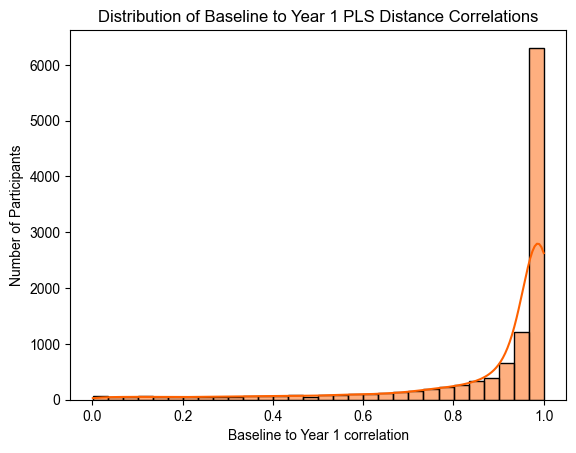

In [15]:
# Plot baseline correlation distribution

baseline_df = baseline_distances_df.set_index('src_subject_id')
year1_df = distances_df_dict['year1'].set_index('src_subject_id')

# Align participants (intersection)
common_ids = baseline_df.index.intersection(year1_df.index)
aligned_baseline = baseline_df.loc[common_ids]
aligned_year1 = year1_df.loc[common_ids]

# Compute row-wise correlation across profiles for each participant
baseline_year1_similarity = aligned_baseline.corrwith(aligned_year1, axis=1)
baseline_year1_similarity_abs = baseline_year1_similarity.abs()

#print(baseline_year1_similarity.head(10))
#print(baseline_year1_similarity.shape)

# Plot distribution
sns.histplot(baseline_year1_similarity_abs, bins=30, kde=True, color='#FE6100')
plt.xlabel('Baseline to Year 1 correlation')
plt.ylabel('Number of Participants')
plt.title('Distribution of Baseline to Year 1 PLS Distance Correlations')
plt.show()

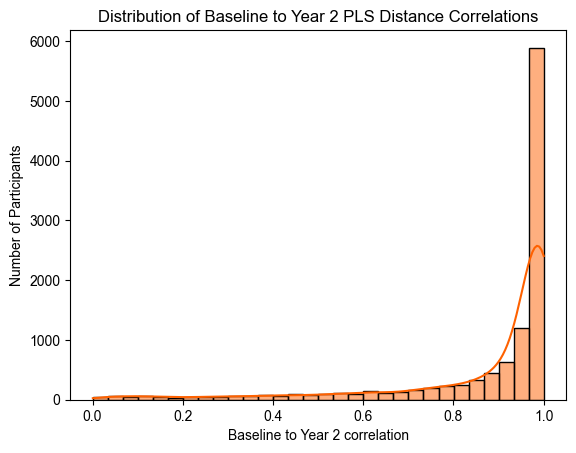

In [16]:
# Plot 2 year follow-up correlation distribution

year2_df = distances_df_dict['year2'].set_index('src_subject_id')

# Align participants (intersection)
common_ids = baseline_df.index.intersection(year2_df.index)
aligned_baseline = baseline_df.loc[common_ids]
aligned_year2 = year2_df.loc[common_ids]

# Compute row-wise correlation across profiles for each participant
baseline_year2_similarity = aligned_baseline.corrwith(aligned_year2, axis=1)
baseline_year2_similarity_abs = baseline_year2_similarity.abs()

#print(baseline_year2_similarity.head(10))
#print(baseline_year2_similarity.shape)

# Plot distribution
sns.histplot(baseline_year2_similarity_abs, bins=30, kde=True, color='#FE6100')
plt.xlabel('Baseline to Year 2 correlation')
plt.ylabel('Number of Participants')
plt.title('Distribution of Baseline to Year 2 PLS Distance Correlations')
plt.show()

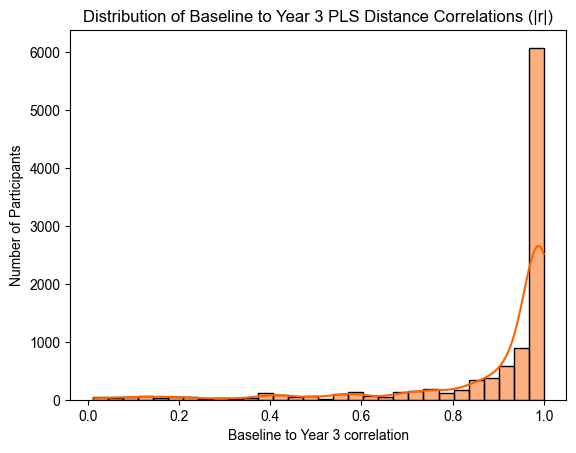

In [17]:
# Plot 3 year follow-up correlation distribution

year3_df = distances_df_dict['year3'].set_index('src_subject_id')

# List of profiles to keep - here drop Mania, as there was no Mania measurement at Year 3. Therefore compare only 9 features at baseline and year 3.
profiles_to_use = [col for col in baseline_df.columns if col != 'Mania_Total']

# Align participants
common_ids = baseline_df.index.intersection(year3_df.index)
aligned_baseline = baseline_df.loc[common_ids, profiles_to_use]
aligned_year3 = year3_df.loc[common_ids, profiles_to_use]

# Compute row-wise correlation
baseline_year3_similarity = aligned_baseline.corrwith(aligned_year3, axis=1)
baseline_year3_similarity_abs = baseline_year3_similarity.abs()

#print(baseline_year3_similarity.head(10))
#print(baseline_year3_similarity.shape)

# Plot distribution
sns.histplot(baseline_year3_similarity_abs, bins=30, kde=True, color='#FE6100')
plt.xlabel('Baseline to Year 3 correlation')
plt.ylabel('Number of Participants')
plt.title('Distribution of Baseline to Year 3 PLS Distance Correlations (|r|)')
plt.show()


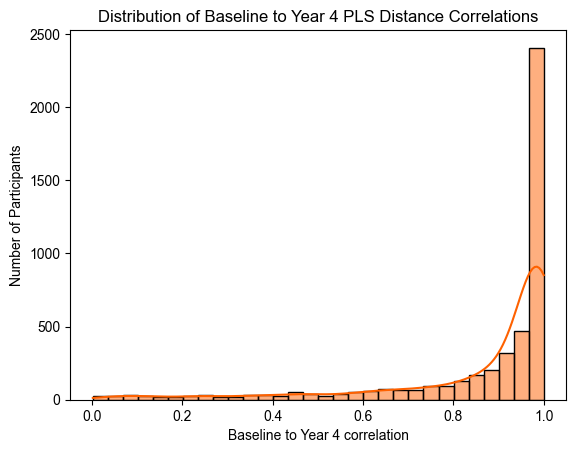

In [18]:
# Plot 4 year follow-up correlation distribution

year4_df = distances_df_dict['year4'].set_index('src_subject_id')

# Align participants (intersection)
common_ids = baseline_df.index.intersection(year4_df.index)
aligned_baseline = baseline_df.loc[common_ids]
aligned_year4 = year4_df.loc[common_ids]

# Compute row-wise correlation across profiles for each participant
baseline_year4_similarity = aligned_baseline.corrwith(aligned_year4, axis=1)
baseline_year4_similarity_abs = baseline_year4_similarity.abs()

#print(baseline_year4_similarity.head(10))
#print(baseline_year4_similarity.shape)

# Plot distribution
sns.histplot(baseline_year4_similarity_abs, bins=30, kde=True, color='#FE6100')
plt.xlabel('Baseline to Year 4 correlation')
plt.ylabel('Number of Participants')
plt.title('Distribution of Baseline to Year 4 PLS Distance Correlations')
plt.show()

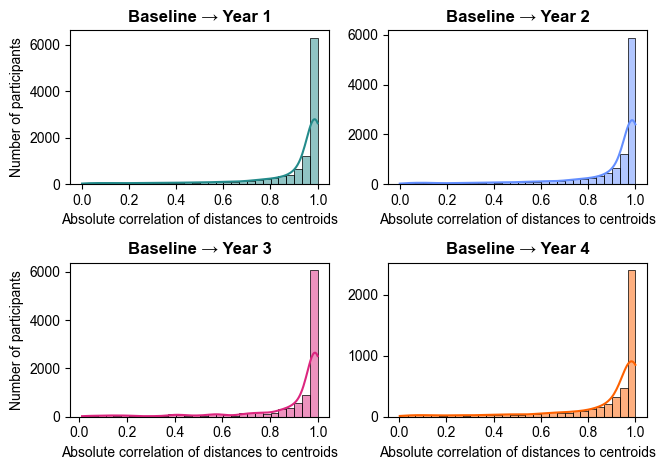

In [19]:
# Create 2x2 subplots for 4 years
fig, axs = plt.subplots(2, 2, figsize=(6.7, 4.8))

'#238B8B', '#648FFF','#DC267F', '#FE6100'

# Plot each year in a separate subplot with KDE
sns.histplot(baseline_year1_similarity_abs, bins=30, kde=True, color="#238B8B", ax=axs[0,0])
axs[0,0].set_title("Baseline → Year 1", fontweight='bold')
axs[0,0].set_xlabel("Absolute correlation of distances to centroids")
axs[0,0].set_ylabel("Number of participants")

sns.histplot(baseline_year2_similarity_abs, bins=30, kde=True, color="#648FFF", ax=axs[0,1])
axs[0,1].set_title("Baseline → Year 2", fontweight='bold')
axs[0,1].set_xlabel("Absolute correlation of distances to centroids")
axs[0,1].set_ylabel("")

sns.histplot(baseline_year3_similarity_abs, bins=30, kde=True, color="#DC267F", ax=axs[1,0])
axs[1,0].set_title("Baseline → Year 3", fontweight='bold')
axs[1,0].set_xlabel("Absolute correlation of distances to centroids")
axs[1,0].set_ylabel("Number of participants")

sns.histplot(baseline_year4_similarity_abs, bins=30, kde=True, color="#FE6100", ax=axs[1,1])
axs[1,1].set_title("Baseline → Year 4", fontweight='bold')
axs[1,1].set_xlabel("Absolute correlation of distances to centroids")
axs[1,1].set_ylabel("")

plt.tight_layout()

fig.savefig("Stability_weightvctrs.png", dpi=600, bbox_inches='tight')
plt.show()
